# Clasificador de Vinos con KNN

Objetivo de este proyecto entrenar un modelo de K-Vecinos más Cercanos (KNN) para predecir la calidad de un vino tinto a partir de sus características químicas. 

## FUENTE :  Wine Quality Data Set - UCI

1. Exportacion de Librerias necesarias, descarga y exploracion del Dataset 

In [1]:
# Librerias necesarias 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
df = pd.read_csv(url, sep=';') 

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


1.2 Preparacion del dataset:

Crear columna 'label' a partir de 'quality' y visualizar distribución

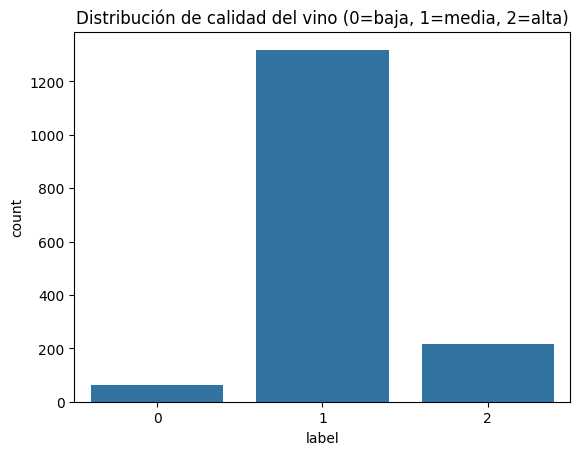

,quality,label
0,5,1
1,5,1
2,5,1
3,6,1
4,5,1


In [6]:
def quality_to_label(q):
    if q <= 4:
        return 0  # baja calidad
    elif q <= 6:
        return 1  # calidad media
    else:
        return 2  # alta calidad

df['label'] = df['quality'].apply(quality_to_label)

# Distribución de etiquetas
sns.countplot(x=df['label'])
plt.title("Distribución de calidad del vino (0=baja, 1=media, 2=alta)")
plt.show()

# Verificar
df[['quality', 'label']].head()



La variable 'quality' tiene valores continuos entre 3 y 8, por lo cual la mejor opcion para luego realizar este modelo KNN es agruparlos en 3 clases para mejorar el rendimiento y estabilidad del modelo de calsificacion. 
Asi difiniendolas en clasificación de calidad baja, media y alta.

Al verificar su distribucion podemos ver un fuerte desbalance entre ellos : 

Clase 1 (calidad media) domina con mucha diferencia.
Clase 0 (baja calidad) y Clase 2 (alta calidad) tienen mucha menos representación.

4. Separar X (features) e y (objetivo)

In [7]:
X = df.drop(['quality', 'label'], axis=1)
y = df['label']

X.shape, y.shape


((1599, 11), (1599,))

5. Dividir en entrenamiento/prueba y escalar

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ver tamaños
{
    "Training set size": len(X_train),
    "Test set size": len(X_test),
    "Features": X_train.shape[1]
}



{'Training set size': 1279, 'Test set size': 320, 'Features': 11}

6.  Entrenar KNN con k=5 y evaluar

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

# Evaluación
accuracy_score(y_test, y_pred)


0.81875

 9. Matriz de confusión y clasificación

In [10]:
confusion_matrix(y_test, y_pred)


array([[  0,  13,   0],
       [  1, 243,  20],
       [  0,  24,  19]])

In [11]:
# Reporte por clase
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.87      0.92      0.89       264
           2       0.49      0.44      0.46        43

    accuracy                           0.82       320
   macro avg       0.45      0.45      0.45       320
weighted avg       0.78      0.82      0.80       320



 10. Optimización de k: Probar varios valores de k (1 a 20)

In [12]:
accuracy_list = []
k_range = range(1, 21)

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    accuracy_list.append(acc)

accuracy_list


[0.81875,
 0.815625,
 0.828125,
 0.828125,
 0.81875,
 0.84375,
 0.84375,
 0.83125,
 0.8375,
 0.846875,
 0.859375,
 0.859375,
 0.84375,
 0.84375,
 0.8375,
 0.8375,
 0.83125,
 0.84375,
 0.8375,
 0.840625]

11. Gráfico de accuracy vs k y mejor valor

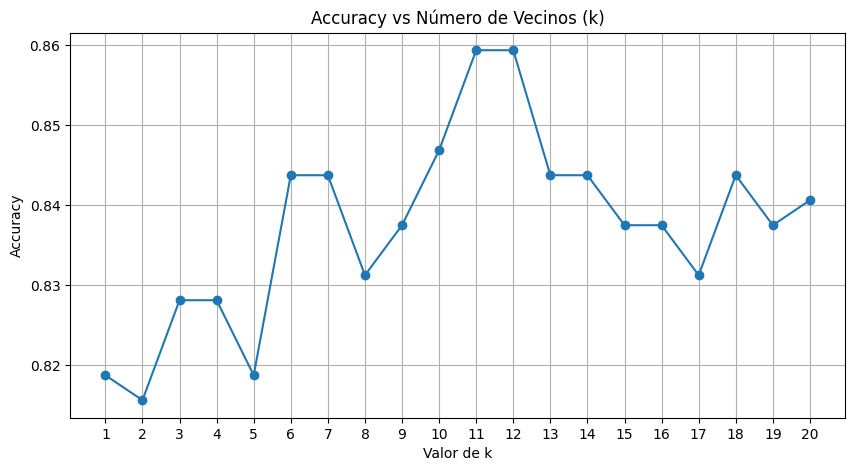

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(k_range, accuracy_list, marker='o')
plt.title("Accuracy vs Número de Vecinos (k)")
plt.xlabel("Valor de k")
plt.ylabel("Accuracy")
plt.xticks(k_range)
plt.grid(True)
plt.show()


In [14]:
best_k = k_range[np.argmax(accuracy_list)]
best_k, max(accuracy_list)


(11, 0.859375)

12. Función para predecir calidad de un vino

In [15]:
def predict_wine_quality(features):
    columnas = X.columns  # usa los nombres originales
    df_input = pd.DataFrame([features], columns=columnas)
    features_scaled = scaler.transform(df_input)
    prediction = best_knn.predict(features_scaled)[0]

    if prediction == 0:
        return "Este vino probablemente sea de **baja calidad**"
    elif prediction == 1:
        return "Este vino probablemente sea de **calidad media**"
    else:
        return "Este vino probablemente sea de **alta calidad**"
 

predict_wine_quality([7.4, 0.7, 0.0, 1.9, 0.076,
                      11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])

NameError: name 'best_knn' is not defined

### Conclusion del Proyecto:
En este proyecto desarrollamos un modelo de clasificación para predecir la calidad de vinos tintos utilizando el algoritmo K-Vecinos más Cercanos (KNN), basado en sus características químicas.

Etapas principales del proyecto:

Carga y exploración del dataset:
Utilizamos el dataset público de vinos tintos del repositorio de UCI. Exploramos su estructura y visualizamos la distribución de la variable objetivo (quality).

Creación de etiquetas (label):
Transformamos la variable continua quality en una variable categórica con tres clases:

-0: baja calidad (≤4)

-1: calidad media (5–6)

-2: alta calidad (≥7)

Preprocesamiento:

- Se separaron las variables independientes (X) y la variable objetivo (y).

- Se dividieron los datos en conjunto de entrenamiento y prueba (80/20), manteniendo el balance de clases con stratify=y.

- Se escalaron los datos con StandardScaler, esencial para un algoritmo como KNN, que depende de distancias entre puntos.

Entrenamiento y evaluación del modelo KNN:

- Se entrenó un modelo inicial con k=5.

- Se evaluó el rendimiento con métricas como accuracy_score, confusion_matrix y classification_report.

- Se probó una gama de valores de k del 1 al 20, y se seleccionó el valor óptimo que ofrecía el mejor desempeño.

Predicción personalizada:

Se construyó una función predict_wine_quality() que permite ingresar características químicas de un vino y obtener su predicción de calidad de forma clara e interpretativa.




### Justificación del resultado: Calidad media

El modelo predice que el vino de prueba tiene calidad media, lo cual es coherente con la realidad del dataset por dos razones principales:

Distribución de clases:
Más del 60% de los vinos del dataset tienen una calidad entre 5 y 6, lo que los clasifica como calidad media. Esto refleja un sesgo natural del conjunto de datos hacia esa clase.

Características químicas del ejemplo:
El vino de prueba tenía valores moderados en acidez, azúcar residual, alcohol y pH, sin valores extremos que lo ubicaran claramente en calidad baja o alta. Esto justifica que el modelo lo clasifique como vino promedio en calidad.

